In [2]:
%load_ext autoreload
%autoreload 2

import os

import torch
import matplotlib.pyplot as plt
import numpy as np
from torch import Tensor
from attrs import asdict
from cattrs import structure
from typing import Any

from src.ds_utils import get_embedding_directory, save_generated_audio, load_audio_tensor
from src.configs import parse_hydra_config
from src.train import TrainingConfig
from src.model import SAMPLING_RATE, VAE, encode_with_model
from src.generate import generate_with_model
from src.evaluations.fad import fad_from_embeddings
from src.evaluations.kid import kid_embeddings

# VCTK words

In [3]:
config_path = "configs/experiment/vctk_words/v8.yaml"
checkpoint_path = "/home/jp/mgr2024/logs/vctk_words/version_14/checkpoints/last.ckpt"
validation_set_path = "/media/Data/jp_dir/sounds/vctk_words_v2/audio_val"
generation_path = "/media/Data/jp_dir/sounds/eval/unconditional_generation"
DEVICE = torch.device("cuda:0")


def get_model(config_path: str, checkpoint_path: str) -> tuple[VAE, dict[str, Any]]:
    cfg = structure(
        parse_hydra_config("/home/jp/mgr2024/configs", config_path),
        TrainingConfig,
    )
    length_in_seconds = cfg.model.fixed_length / SAMPLING_RATE

    model = VAE.load_from_checkpoint(checkpoint_path, noise_config=cfg.noise, **asdict(cfg.model), map_location=DEVICE, weights_only=False).to(DEVICE)
    model.eval()
    return model, {
        "length_seconds": length_in_seconds,
        "latent_size": cfg.model.latent_size
    }

model, selected_configuration = get_model(config_path, checkpoint_path)

/home/jp/miniconda3/envs/mgr/lib/python3.10/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'default': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)
/home/jp/miniconda3/envs/mgr/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/home/jp/miniconda3/envs/mgr/lib/python3.10/site-packages/torchaudio/transforms/_transforms.py:94: UserWarning: `return_complex` argument is now deprecated and is not effective.`torchaudio.transforms.Spectrogram(power=None)` always returns a tensor with complex dtype. Please remove the argument in the function call.
  warnings.warn(


In [4]:
validation_embeddings_path = get_embedding_directory(validation_set_path, selected_configuration["length_seconds"])
validation_embeddings_path

'/media/Data/jp_dir/sounds/vctk_words_v2/audio_val_embeddings'

In [5]:
from sklearn.decomposition import PCA


def plot_3d_points(*point_sets, labels=None, figsize=(10, 8), alpha=0.6, marker='o', s=20):
    """
    Visualize multiple sets of 3D points, each with a distinct color.

    Args:
        *point_sets: Each argument should be an (N, 3) array of 3D points.
        labels:      Optional list of names for the legend.
        figsize:     Figure size.
        alpha:       Point transparency.
        marker:      Marker style.
        s:           Marker size.
    """
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')

    colors = plt.cm.tab10(np.linspace(0, 1, len(point_sets)))

    for i, points in enumerate(point_sets):
        points = np.array(points)  # ensure numpy array
        label = labels[i] if labels and i < len(labels) else f"Group {i}"
        ax.scatter(points[:, 0], points[:, 1], points[:, 2],
                   c=[colors[i]], label=label, alpha=alpha, marker=marker, s=s)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_pca(*data: Tensor, names: list[str] = list()) -> None:
    pca = PCA(3).fit(torch.concatenate(tuple(data)).cpu().numpy())
    plot_3d_points(*map(pca.transform, data), labels=names)

print("ok")

ok


In [6]:
from pathlib import Path

_gen_embedding_path = f"{generation_path}/vctk_words_notebook_eval"
if not Path(_gen_embedding_path).exists():
    generated = generate_with_model(model, 500, selected_configuration["latent_size"])
    save_generated_audio(generated, _gen_embedding_path, SAMPLING_RATE)
generated_embeddings_path = get_embedding_directory(_gen_embedding_path, selected_configuration["length_seconds"])
generated_embeddings_path

'/media/Data/jp_dir/sounds/eval/unconditional_generation/vctk_words_notebook_eval_embeddings'

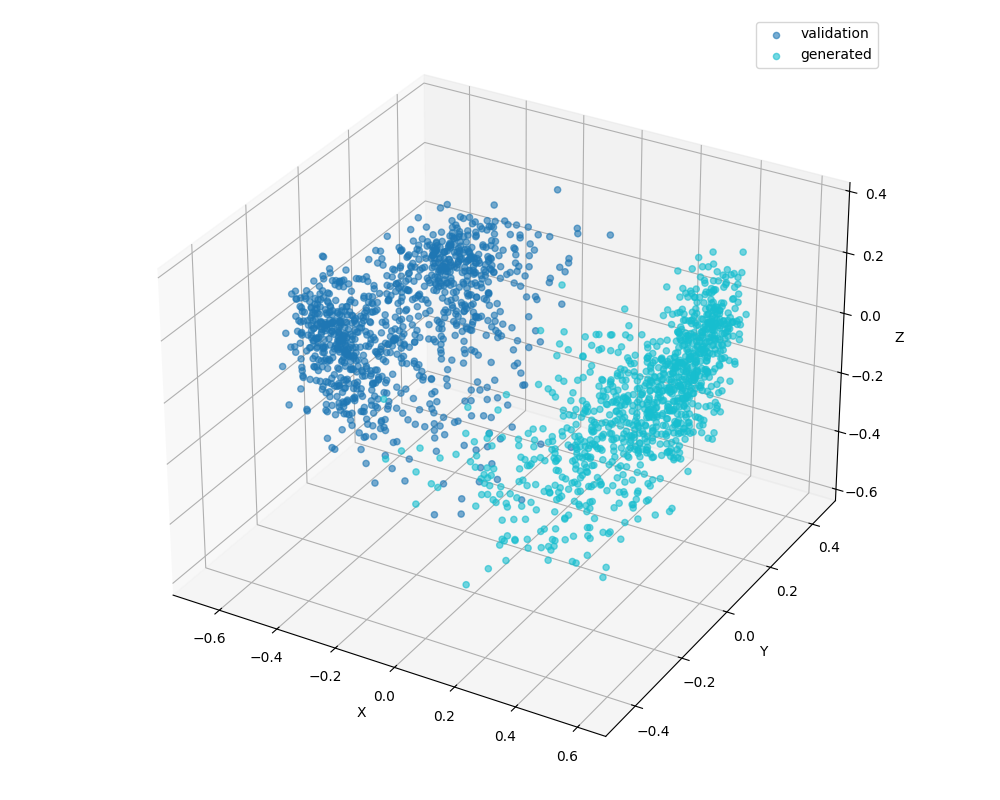

In [29]:
%matplotlib widget

import random

generated_embeddings = load_audio_tensor(generated_embeddings_path).data
validation_embeddings = load_audio_tensor(validation_embeddings_path).data[random.sample(range(24000), 1000), ...]
plot_pca(validation_embeddings, generated_embeddings, names=("validation", "generated"))

In [7]:
generated_embeddings = load_audio_tensor(generated_embeddings_path).data
fad_score = fad_from_embeddings(load_audio_tensor(validation_embeddings_path).data, generated_embeddings)
fad_score

FADInfResults(score=0.78149166972251, slope=7.54480215721149, r2=0.06945120527046955, points=[[500, 0.7904891727966166], [520, 0.7871580995537872], [541, 0.7976999057397793], [562, 0.8048764227596609], [583, 0.7937559172481103], [604, 0.800065708234168], [625, 0.7868282897683724], [645, 0.7780661816543586], [666, 0.8079241981217526], [687, 0.7960429892728207], [708, 0.7966300841042039], [729, 0.7895223953046022], [750, 0.8028095846980587], [770, 0.7868369306899137], [791, 0.7931867554306924], [812, 0.7916494399664342], [833, 0.7931725764498083], [854, 0.7888474417614163], [875, 0.7946019222757621], [895, 0.7959827625240774], [916, 0.7730747813794359], [937, 0.7809915114146815], [958, 0.7990516830640444], [979, 0.7941402437860838], [1000, 0.7764236464121035]])

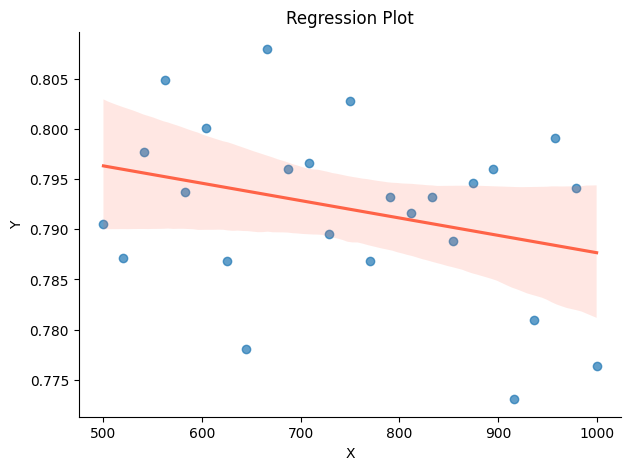

In [8]:
%matplotlib inline

import matplotlib
matplotlib.use('Agg')  # or 'inline'

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display

points = fad_score.points

x, y = zip(*points)

fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(x=np.array(x), y=np.array(y), ax=ax, 
            scatter_kws={"alpha": 0.7}, line_kws={"color": "tomato"})
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Regression Plot")
sns.despine()

display(fig)
plt.close(fig)

In [9]:
from src.evaluations.kid import kid_embeddings

kid_embeddings(generated_embeddings, load_audio_tensor(validation_embeddings_path).data)

0.8916075825691223